In [1]:
# Celula 1 - Imports
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.diabetes.dataset import load_diabetes_dataframe, get_diabetes_info

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('Imports carregados')

Imports carregados


In [2]:
# Celula 2 - Informacoes do dataset
info = get_diabetes_info()
for k, v in info.items():
    if k != 'feature_descriptions':
        print(f'{k}: {v}')

print('\nDescricao das features:')
for feat, desc in info['feature_descriptions'].items():
    print(f'  - {feat}: {desc}')

name: Pima Indians Diabetes Database
samples: 768
features: 8
classes: ['No diabetes', 'Diabetes']
task: classification

Descricao das features:
  - pregnancies: Numero de gestacoes
  - glucose: Nivel de glicose plasmatica (mg/dL)
  - blood_pressure: Pressao arterial diastolica (mm Hg)
  - skin_thickness: Espessura da dobra cutanea (mm)
  - insulin: Insulina serica (mu U/mL)
  - bmi: Indice de massa corporal (kg/m2)
  - diabetes_pedigree: Funcao de pedigree de diabetes
  - age: Idade (anos)


In [3]:
# Celula 3 - Carregar dados
df = load_diabetes_dataframe()
print(f'Shape: {df.shape}')
print('\nPrimeiras 5 linhas:')
df.head()

Shape: (768, 9)

Primeiras 5 linhas:


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Celula 4 - Qualidade dos dados (nulos e zeros impossiveis)
print('Info do DataFrame:')
df.info()

print('\nValores ausentes por coluna:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Nenhum valor ausente!')

# No Pima, valores 0 em glicose/pressao/IMC sao biologicamente impossiveis
zero_cols = ['glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi']
print('\nValores zero (impossiveis, tratados como ausentes) por coluna:')
for col in zero_cols:
    n_zeros = int((df[col] == 0).sum())
    print(f'  - {col}: {n_zeros} ({n_zeros / len(df) * 100:.1f}%)')

print('\nEstatisticas descritivas:')
df.describe().T

Info do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pregnancies        768 non-null    int64  
 1   glucose            768 non-null    int64  
 2   blood_pressure     768 non-null    int64  
 3   skin_thickness     768 non-null    int64  
 4   insulin            768 non-null    int64  
 5   bmi                768 non-null    float64
 6   diabetes_pedigree  768 non-null    float64
 7   age                768 non-null    int64  
 8   outcome            768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Valores ausentes por coluna:
Nenhum valor ausente!

Valores zero (impossiveis, tratados como ausentes) por coluna:
  - glucose: 5 (0.7%)
  - blood_pressure: 35 (4.6%)
  - skin_thickness: 227 (29.6%)
  - insulin: 374 (48.7%)
  - bmi: 11 (1.4%)

Estatisticas descritivas:


,count,mean,std,min,25%,50%,75%,max
pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
blood_pressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
skin_thickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
bmi,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
diabetes_pedigree,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


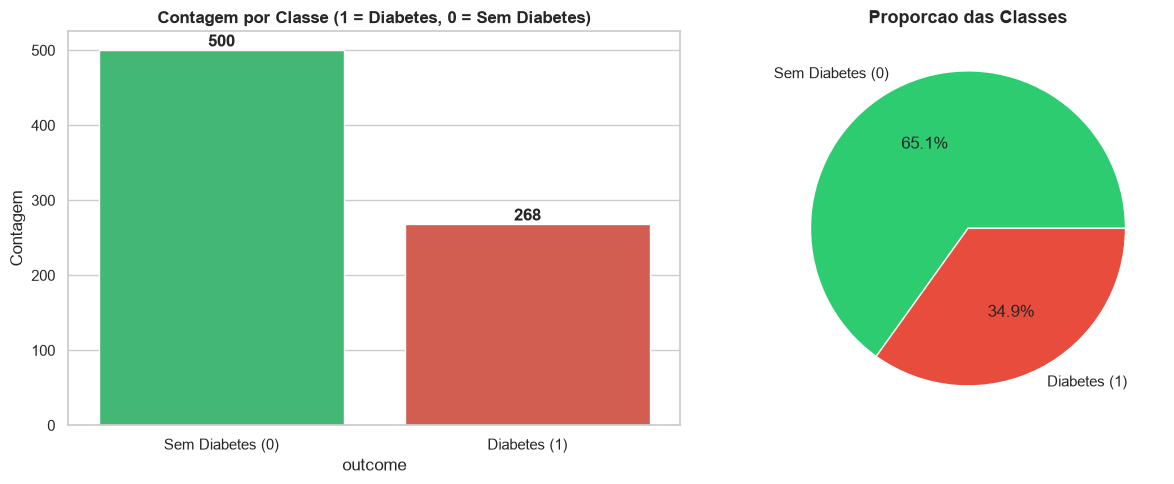

Distribuicao:
outcome
0    500
1    268
Name: count, dtype: int64

Proporcao Diabetes: 34.9% | Sem Diabetes: 65.1%


In [5]:
# Celula 5 - Distribuicao da variavel target (1 = diabetes, 0 = sem diabetes)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df['outcome'].value_counts().sort_index()
sns.countplot(x='outcome', hue='outcome', data=df,
              palette=['#2ecc71', '#e74c3c'], legend=False, ax=axes[0])
axes[0].set_title('Contagem por Classe (1 = Diabetes, 0 = Sem Diabetes)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('outcome')
axes[0].set_ylabel('Contagem')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Sem Diabetes (0)', 'Diabetes (1)'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

df['outcome'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    labels=['Sem Diabetes (0)', 'Diabetes (1)'], ax=axes[1]
)
axes[1].set_title('Proporcao das Classes', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

print('Distribuicao:')
print(df['outcome'].value_counts().sort_index())
print(f'\nProporcao Diabetes: {df["outcome"].mean()*100:.1f}% | Sem Diabetes: {(1-df["outcome"].mean())*100:.1f}%')

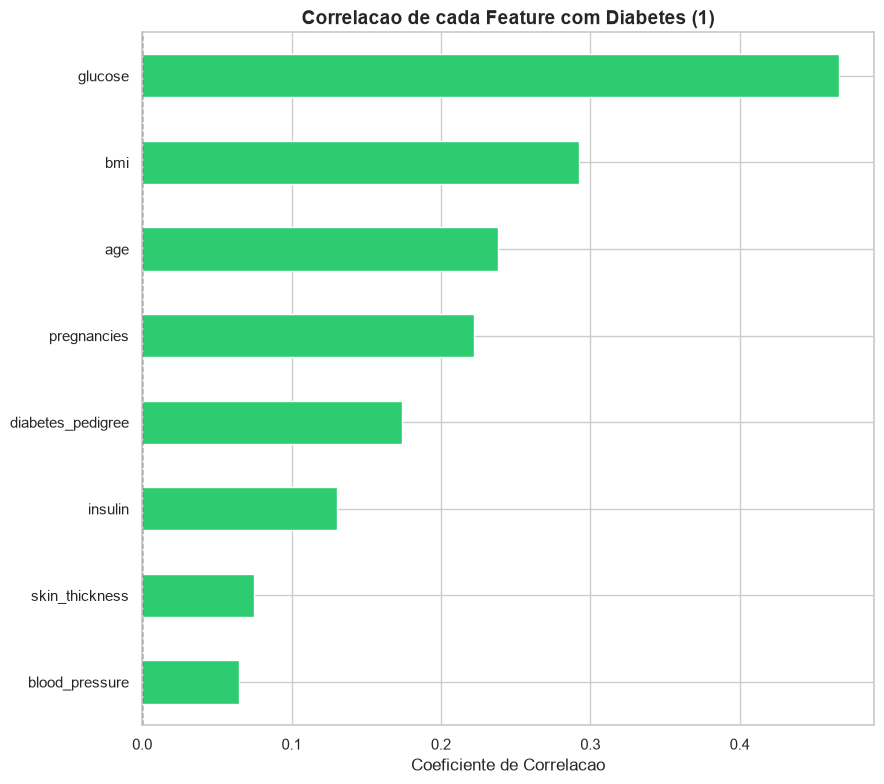

Correlacoes com o target (ordenadas):
blood_pressure       0.065
skin_thickness       0.075
insulin              0.131
diabetes_pedigree    0.174
pregnancies          0.222
age                  0.238
bmi                  0.293
glucose              0.467
dtype: float64


In [6]:
# Celula 6 - Correlacao das features com o target
features = [c for c in df.columns if c != 'outcome']
corr_with_target = df[features].corrwith(df['outcome']).sort_values()

plt.figure(figsize=(9, 8))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in corr_with_target.values]
corr_with_target.plot(kind='barh', color=colors)
plt.title('Correlacao de cada Feature com Diabetes (1)', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente de Correlacao')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

print('Correlacoes com o target (ordenadas):')
print(corr_with_target.round(3))

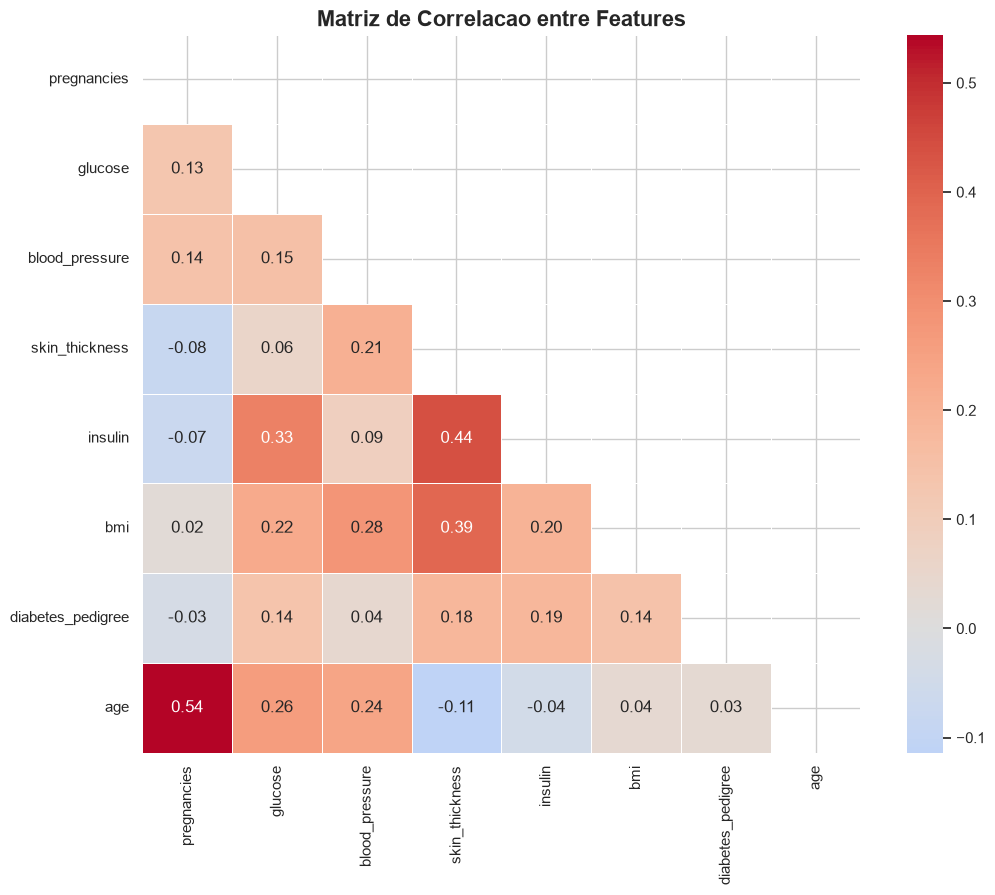

In [7]:
# Celula 7 - Matriz de correlacao completa
plt.figure(figsize=(11, 9))
corr_matrix = df[features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5)
plt.title('Matriz de Correlacao entre Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

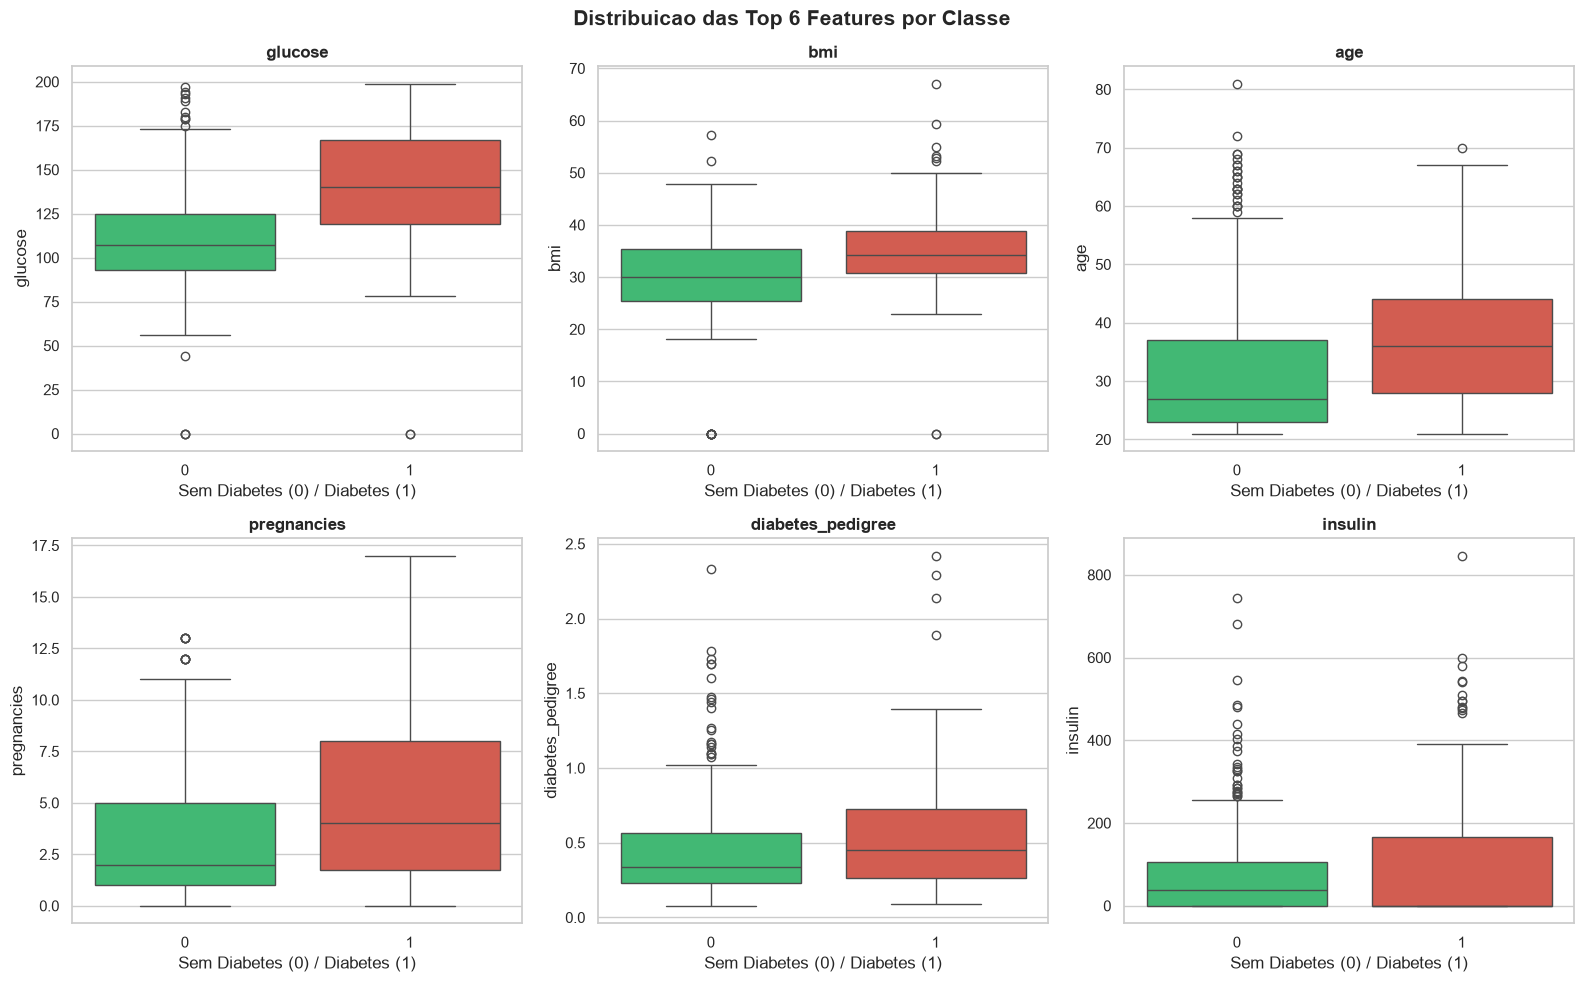

In [8]:
# Celula 8 - Boxplots das top 6 features por classe
top_features = corr_with_target.abs().sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for idx, feature in enumerate(top_features):
    sns.boxplot(x='outcome', y=df[feature], hue='outcome', data=df,
                palette=['#2ecc71', '#e74c3c'], legend=False, ax=axes[idx])
    axes[idx].set_title(feature, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Sem Diabetes (0) / Diabetes (1)')
plt.suptitle('Distribuicao das Top 6 Features por Classe', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [9]:
# Celula 9 - Estatisticas por classe
print('Estatisticas descritivas por classe (media das features):')
stats = df.groupby('outcome')[features].mean().T
stats.columns = ['Sem Diabetes (0)', 'Diabetes (1)']
stats['diferenca'] = (stats['Diabetes (1)'] - stats['Sem Diabetes (0)']).round(3)
stats.round(3)

Estatisticas descritivas por classe (media das features):


,Sem Diabetes (0),Diabetes (1),diferenca
pregnancies,3.298,4.866,1.568
glucose,109.980,141.257,31.277
blood_pressure,68.184,70.825,2.641
skin_thickness,19.664,22.164,2.500
insulin,68.792,100.336,31.544
bmi,30.304,35.143,4.838
diabetes_pedigree,0.430,0.550,0.121
age,31.190,37.067,5.877


In [10]:
# Celula 10 - Insights e conclusoes
print('''
=========== INSIGHTS DA ANALISE EXPLORATORIA ===========
1. DATASET: 768 amostras, 8 features + outcome (0/1).
2. VALORES ZERO IMPOSSIVEIS: glicose, pressao arterial, dobra cutanea,
   insulina e IMC apresentam zeros que representam dados ausentes
   (ex: glicose = 0 mg/dL nao existe). Devem ser tratados antes do treino.
3. CLASSES DESBALANCEADAS: ~65/35 - usar stratify no split e metricas
   como AUC/F1 (nao so acuracia).
4. FEATURES MAIS RELEVANTES: glucose e a feature mais correlacionada
   com o diagnostico, seguida de bmi e age.
5. ESCALA DIFERENTE: glucose (~0-200) vs diabetes_pedigree (~0-2) ->
   usar StandardScaler antes do treino.
6. PRE-PROCESSAMENTO RECOMENDADO: tratar zeros como NaN + imputacao,
   StandardScaler + stratified split.
=========================================================
''')


=========== INSIGHTS DA ANALISE EXPLORATORIA ===========
1. DATASET: 768 amostras, 8 features + outcome (0/1).
2. VALORES ZERO IMPOSSIVEIS: glicose, pressao arterial, dobra cutanea,
   insulina e IMC apresentam zeros que representam dados ausentes
   (ex: glicose = 0 mg/dL nao existe). Devem ser tratados antes do treino.
3. CLASSES DESBALANCEADAS: ~65/35 - usar stratify no split e metricas
   como AUC/F1 (nao so acuracia).
4. FEATURES MAIS RELEVANTES: glucose e a feature mais correlacionada
   com o diagnostico, seguida de bmi e age.
5. ESCALA DIFERENTE: glucose (~0-200) vs diabetes_pedigree (~0-2) ->
   usar StandardScaler antes do treino.
6. PRE-PROCESSAMENTO RECOMENDADO: tratar zeros como NaN + imputacao,
   StandardScaler + stratified split.

